# Train and Visualize a Field Segmentation Experiment

This notebook is the main workflow for Colab or local training. It loads an experiment config, prepares FTW data when available, trains the model, evaluates metrics, and shows predictions.

In [2]:
from pathlib import Path
import os
import sys

# Edit these three values if your Colab/Drive setup changes.
PROJECT_ROOT = Path('/content/drive/My Drive/HLCV_final_project')
FTW_ZIP = Path('/content/drive/MyDrive/ftw_france_subset.zip')
FTW_COUNTRY = 'france'

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
else:
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'Project folder not found: {PROJECT_ROOT}')
if not (PROJECT_ROOT / 'requirements.txt').exists():
    raise FileNotFoundError(f'requirements.txt not found under: {PROJECT_ROOT}')

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Using project root: {PROJECT_ROOT}')
print(f'Using FTW zip: {FTW_ZIP}')
print(f'Using FTW country: {FTW_COUNTRY}')
print(f'Current working directory: {Path.cwd()}')

Using project root: /Users/daddysugar/Documents/Lectures/HLCV/HLCV_final_project
Using FTW zip: /content/drive/MyDrive/ftw_france_subset.zip
Using FTW country: france
Current working directory: /Users/daddysugar/Documents/Lectures/HLCV/HLCV_final_project


In [13]:
# Run once in each fresh Colab runtime.
%pip install -q -r requirements.txt

Exception ignored in: <function tqdm.__del__ at 0x7e67a98f7f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


In [14]:
# Optional for FTW training: unzip your Drive archive into fast Colab local storage.
# This handles both zip styles: either containing `france/` or containing the contents of `france/`.
from pathlib import Path
import shutil
import subprocess

LOCAL_DATA_ROOT = Path('/content/data')
LOCAL_FTW_ROOT = LOCAL_DATA_ROOT / 'ftw'

def has_ftw_country_payload(path, country=FTW_COUNTRY):
    path = Path(path)
    return (
        path.is_dir()
        and (path / 's2_images').is_dir()
        and (path / 'label_masks').is_dir()
        and ((path / f'chips_{country}.parquet').exists() or (path / 's2_images' / 'window_a').is_dir())
    )

def normalize_ftw_country_folder(source_dir, country=FTW_COUNTRY):
    source_dir = Path(source_dir)
    target_dir = LOCAL_FTW_ROOT / country
    if source_dir.resolve() == target_dir.resolve():
        return target_dir.parent
    target_dir.mkdir(parents=True, exist_ok=True)
    for name in [f'chips_{country}.parquet', 's2_images', 'label_masks']:
        src = source_dir / name
        dst = target_dir / name
        if src.exists() and not dst.exists():
            shutil.move(str(src), str(dst))
    return target_dir.parent

def find_ftw_data_root(search_root=LOCAL_DATA_ROOT, country=FTW_COUNTRY):
    search_root = Path(search_root)
    if not search_root.exists():
        return None
    for candidate in [search_root / 'ftw' / country, search_root / country, search_root]:
        if has_ftw_country_payload(candidate, country):
            return normalize_ftw_country_folder(candidate, country)
    for country_dir in search_root.rglob(country):
        if has_ftw_country_payload(country_dir, country):
            return normalize_ftw_country_folder(country_dir, country)
    for parquet in search_root.rglob(f'chips_{country}.parquet'):
        country_dir = parquet.parent
        if has_ftw_country_payload(country_dir, country):
            return normalize_ftw_country_folder(country_dir, country)
    return None

if IN_COLAB:
    LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)
    if find_ftw_data_root() is None and FTW_ZIP.exists():
        subprocess.run(['unzip', '-q', str(FTW_ZIP), '-d', str(LOCAL_DATA_ROOT)], check=True)
    ftw_data_root = find_ftw_data_root()
    if ftw_data_root is None:
        print(f'No FTW data found under {LOCAL_DATA_ROOT}. Upload {FTW_ZIP.name} to MyDrive or update FTW_ZIP.')
    else:
        print(f'FTW data root for config: {ftw_data_root}')
else:
    print('Not running in Colab; local data paths are unchanged.')

FTW data root for config: /content/data/ftw


In [15]:
# GPU check. In Colab, use Runtime > Change runtime type > GPU if this shows no GPU.
!nvidia-smi

import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')

Sat Jul  4 12:20:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   46C    P0             29W /   72W |     260MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from copy import deepcopy
import matplotlib.pyplot as plt

from cfgs import field_segmentation
from src.utils.utils import seed_everything
from src.utils.visualization import show_batch, show_predictions

CONFIG_NAME = 'ftw_dual_head_boundary_bce'  # options: synthetic_debug, ftw_mask_baseline, ftw_dual_head, ftw_dual_head_boundary_bce
NOTEBOOK_NUM_WORKERS = 0  # Colab-quiet setting; use 2 or 6 only if you accept multiprocessing cleanup warnings
MAX_NOTEBOOK_EPOCHS = None  # set to None for the config default
PRECOMPUTE_SDF_CACHE = True

seed_everything(0)
config = deepcopy(getattr(field_segmentation, CONFIG_NAME))

if 'data_dir' in config['data_args']:
    local_ftw_root = find_ftw_data_root() if 'find_ftw_data_root' in globals() else None
    if local_ftw_root is not None:
        config['data_args']['data_dir'] = str(local_ftw_root)
        print(f"Using local FTW data root: {config['data_args']['data_dir']}")
    else:
        print(f"Using configured FTW data root: {config['data_args']['data_dir']}")

config['data_args']['num_workers'] = NOTEBOOK_NUM_WORKERS
if 'sdf_cache_dir' in config['data_args']:
    config['data_args']['sdf_cache_dir'] = '/content/sdf_cache'
config['data_args']['pin_memory'] = True
if NOTEBOOK_NUM_WORKERS > 0:
    config['data_args']['prefetch_factor'] = 2
else:
    config['data_args'].pop('prefetch_factor', None)
    config['data_args'].pop('persistent_workers', None)
if MAX_NOTEBOOK_EPOCHS is not None:
    config['trainer_config']['epochs'] = MAX_NOTEBOOK_EPOCHS

config['name'], config['model_arch'].__name__, config['data_args'], config['criterion_args']

Using local FTW data root: /content/data/ftw


('ftw_dual_head',
 'DualHeadUNet',
 {'data_dir': '/content/data/ftw',
  'image_size': 256,
  'batch_size': 16,
  'shuffle': True,
  'max_train_samples': 8000,
  'heldout_split': 0.0,
  'num_workers': 6,
  'sdf_cache_dir': '/content/sdf_cache',
  'train_augment': True,
  'color_jitter': 0.12,
  'pin_memory': True,
  'prefetch_factor': 2},
 {'bce_weight': 1.0,
  'dice_weight': 1.0,
  'distance_weight': 0.5,
  'tv_weight': 1e-06})

## Precompute SDF Cache

This CPU-only warmup fills `/content/sdf_cache` before training, so the GPU is less likely to wait for SciPy distance transforms during each epoch.

In [17]:
if PRECOMPUTE_SDF_CACHE and 'sdf_cache_dir' in config['data_args']:
    precompute_args = deepcopy(config['data_args'])
    precompute_args['shuffle'] = False
    precompute_args['num_workers'] = 0
    precompute_args.pop('pin_memory', None)
    precompute_args.pop('persistent_workers', None)
    precompute_args.pop('prefetch_factor', None)

    precompute_dm = config['datamodule'](**precompute_args)
    result = precompute_dm.precompute_sdf_cache(include_heldout=True, include_test=False)
    print(result)
else:
    print('Skipping SDF cache precompute.')

{'computed': 0, 'skipped': 2124, 'total': 2124, 'cache_dir': '/content/sdf_cache'}


## Load Data

The data module returns images, binary masks, instance IDs, and signed-distance-field targets. For Colab FTW runs, the setup cells above unpack the data into `/content/data/ftw` and update the config automatically.

Batch image shape: (16, 8, 256, 256)
Batch mask shape: (16, 1, 256, 256)
Batch distance shape: (16, 1, 256, 256)
Train images: 1785
Validation images: 339
Train batches: 112
Validation batches: 22


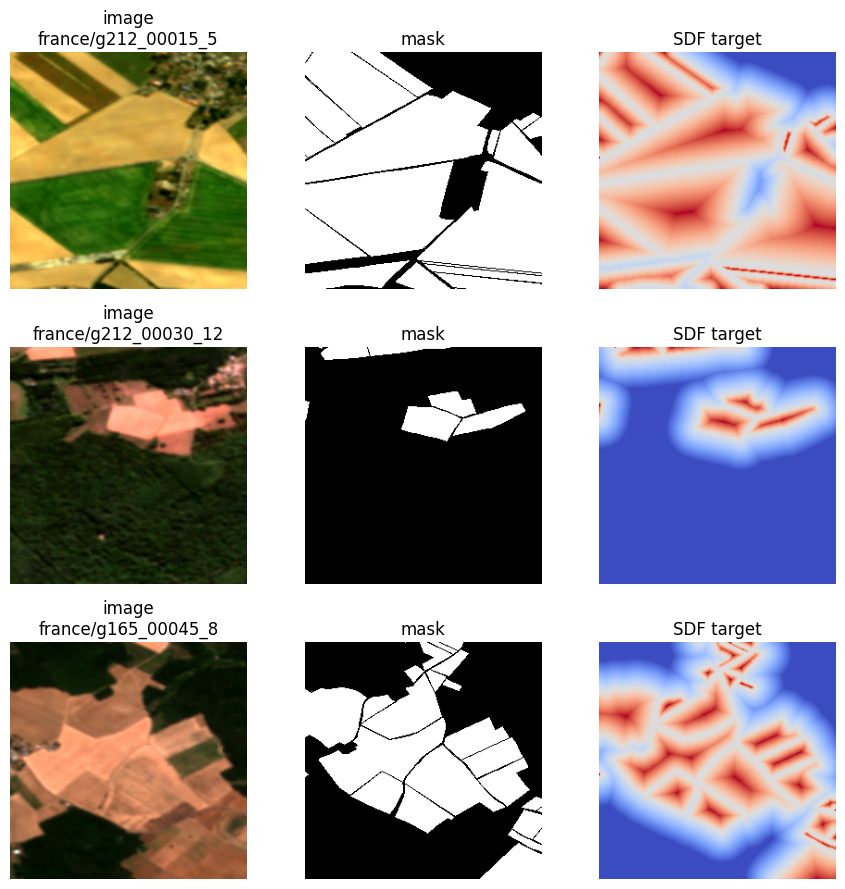

In [18]:
dm = config['datamodule'](**config['data_args'])
train_loader = dm.get_loader()
valid_loader = dm.get_heldout_loader()

batch = next(iter(train_loader))
print('Batch image shape:', tuple(batch['image'].shape))
print('Batch mask shape:', tuple(batch['mask'].shape))
print('Batch distance shape:', tuple(batch['distance'].shape))
print('Train images:', len(train_loader.dataset))
print('Validation images:', len(valid_loader.dataset))
print('Train batches:', len(train_loader))
print('Validation batches:', len(valid_loader))
show_batch(batch, max_items=3);

## Train

Use `MAX_NOTEBOOK_EPOCHS` in the setup cell for quick tests. Set it to `None` to run the full config.

In [19]:
import time

trainer = config['trainer_module'](
    config=config,
    log_dir=PROJECT_ROOT / 'Logs',
    train_loader=train_loader,
    eval_loader=valid_loader,
)
start_time = time.time()
history = trainer.train()
print(f'Training minutes: {(time.time() - start_time) / 60:.2f}')
history

INFO:ftw_dual_head:DualHeadUNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(8, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fals

Epoch 1:   0%|          | 0/112 [00:00<?, ?it/s]

INFO:ftw_dual_head:epoch: 1 | loss: 0.8224 | bce: 0.4210 | dice_loss: 0.3580 | distance_loss: 0.0831 | tv_loss: 1922.3532


epoch: 1 | loss: 0.8224 | bce: 0.4210 | dice_loss: 0.3580 | distance_loss: 0.0831 | tv_loss: 1922.3532


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e67aa109440>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
     ^^^

...

Epoch 30:   0%|          | 0/112 [00:00<?, ?it/s]

Eval:   0%|          | 0/22 [00:00<?, ?it/s]

INFO:ftw_dual_head:epoch: 30 | loss: 0.5100 | bce: 0.2798 | dice_loss: 0.2052 | distance_loss: 0.0453 | tv_loss: 2378.0145 | eval_loss: 0.6083 | eval_bce: 0.2768 | eval_dice_loss: 0.3052 | eval_distance_loss: 0.0489 | eval_tv_loss: 1887.8494 | eval_miou: 0.7445 | eval_boundary_iou: 0.3918


epoch: 30 | loss: 0.5100 | bce: 0.2798 | dice_loss: 0.2052 | distance_loss: 0.0453 | tv_loss: 2378.0145 | eval_loss: 0.6083 | eval_bce: 0.2768 | eval_dice_loss: 0.3052 | eval_distance_loss: 0.0489 | eval_tv_loss: 1887.8494 | eval_miou: 0.7445 | eval_boundary_iou: 0.3918
Training minutes: 14.95


[{'epoch': 1,
  'loss': 0.8224472100181239,
  'bce': 0.42100508511066437,
  'dice_loss': 0.3579722855772291,
  'distance_loss': 0.0830949795698481,
  'tv_loss': 1922.3531788417272},
 {'epoch': 2,
  'loss': 0.7261099932449204,
  'bce': 0.3769652359187603,
  'dice_loss': 0.3106448921774115,
  'distance_loss': 0.07383609958924353,
  'tv_loss': 1581.8198569161552},
 {'epoch': 3,
  'loss': 0.6862974773560252,
  'bce': 0.35901434320424286,
  'dice_loss': 0.29106238910130094,
  'distance_loss': 0.06910720723681152,
  'tv_loss': 1667.144300188337},
 {'epoch': 4,
  'loss': 0.6614233468260083,
  'bce': 0.3511866921825068,
  'dice_loss': 0.27578025151576313,
  'distance_loss': 0.06534874309519571,
  'tv_loss': 1782.0302549089704},
 {'epoch': 5,
  'loss': 0.6428943052887917,
  'bce': 0.3438330441713333,
  'dice_loss': 0.265797563961574,
  'distance_loss': 0.06282278383150697,
  'tv_loss': 1852.3028913225446,
  'eval_loss': 0.6540923782370307,
  'eval_bce': 0.2866383939134804,
  'eval_dice_loss': 0

In [20]:
eval_result = trainer.evaluate(valid_loader)
eval_result

Eval:   0%|          | 0/22 [00:00<?, ?it/s]

{'loss': 0.6083304204724052,
 'bce': 0.2768061790530654,
 'dice_loss': 0.3051719313318079,
 'distance_loss': 0.04892892452930524,
 'tv_loss': 1887.8493902033026,
 'miou': 0.7445041103796526,
 'boundary_iou': 0.39176924458958884}

## Visualize Predictions

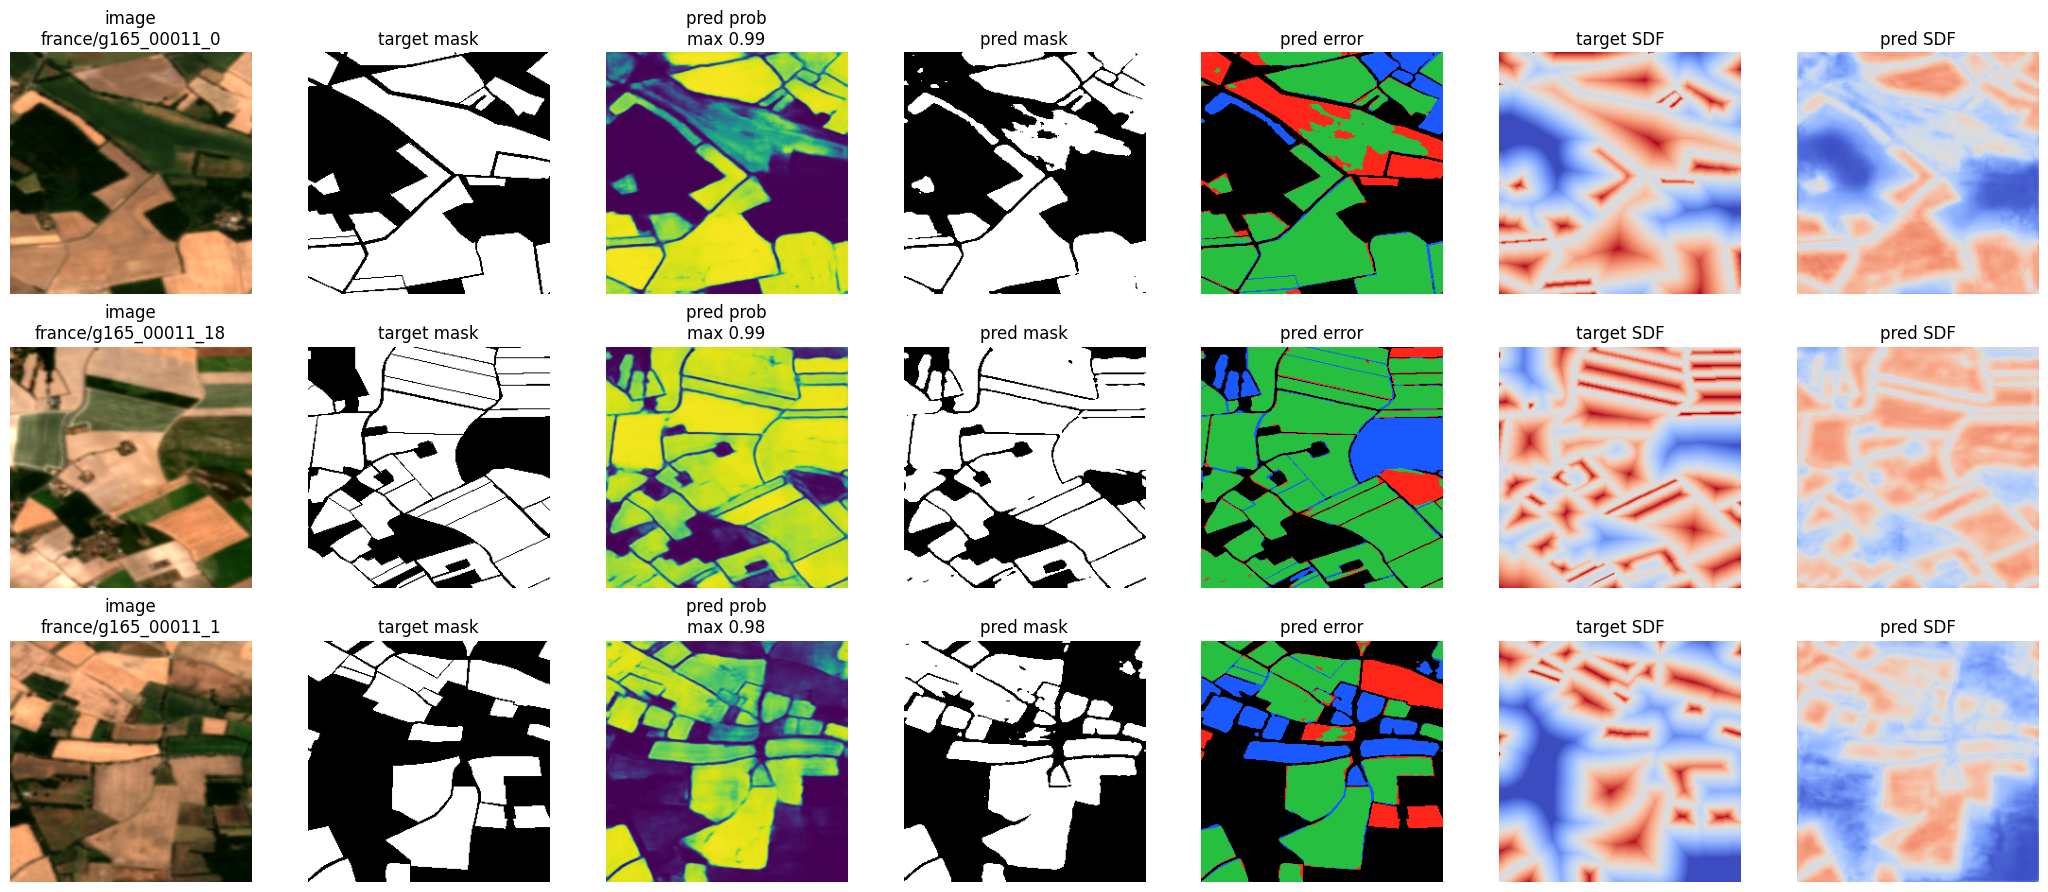

In [22]:
batch = next(iter(valid_loader))
show_predictions(trainer.model, batch, device=trainer.device, max_items=3);

## Checkpoints

The final model weights are saved under `Saved/<experiment_name>/last_model.pth`.

## Evaluate Saved Checkpoints

Run this after both the baseline and dual-head checkpoints exist. It evaluates the same validation split at multiple probability thresholds.

In [ ]:
import subprocess
import sys

evaluation_command = [
    sys.executable,
    'scripts/evaluation/evaluate_checkpoints.py',
    '--models', 'baseline', 'dual_mask', 'dual_sdf_pred',
    '--split', 'val',
    '--baseline-checkpoint', 'Saved/ftw_mask_baseline/last_model.pth',
    '--dual-checkpoint', 'Saved/ftw_dual_head/last_model.pth',
    '--thresholds', '0.5', '0.6', '0.7',
]

result = subprocess.run(
    evaluation_command,
    cwd=PROJECT_ROOT,
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f'evaluate_checkpoints.py failed with exit code {result.returncode}')


NameError: name 'PROJECT_ROOT' is not defined

## Save and Display Visualizations

This block saves a prediction panel from the in-memory model trained above and a label-layout diagnostic panel. It still works when checkpoint saving is disabled.


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image as IPythonImage, display
from matplotlib.colors import ListedColormap
from scipy.ndimage import label as connected_components

VIS_ROOT = PROJECT_ROOT / 'Visualizations'
VIS_ROOT.mkdir(parents=True, exist_ok=True)

# 1) Prediction panel from the model trained in this notebook.
# This does not require Saved/<config>/last_model.pth.
prediction_dir = VIS_ROOT / config['name']
prediction_dir.mkdir(parents=True, exist_ok=True)

vis_batch = next(iter(valid_loader))
fig = show_predictions(
    trainer.model,
    vis_batch,
    device=trainer.device,
    max_items=6,
    threshold=0.5,
    prediction_args=config.get('prediction_args', {}),
)
prediction_path = prediction_dir / 'colab_val_predictions.png'
fig.savefig(prediction_path, dpi=180, bbox_inches='tight')
plt.close(fig)
print(f'Saved prediction panel: {prediction_path}')
display(IPythonImage(filename=str(prediction_path)))

# 2) Label-layout diagnostic panel from the current validation loader.
# This shows why a binary semantic mask can merge neighboring field instances.
def _display_image_for_notebook(image):
    image = image.detach().cpu().float()
    preview = image[0] if image.shape[0] == 1 else image[:3].permute(1, 2, 0)
    low = torch.quantile(preview, 0.02)
    high = torch.quantile(preview, 0.98)
    if float(high - low) > 1e-6:
        preview = (preview - low) / (high - low)
    return preview.clamp(0, 1)


def _colorize_labels(labels):
    labels = np.asarray(labels)
    max_label = int(labels.max()) if labels.size else 0
    if max_label == 0:
        return labels, 'gray'
    rng = np.random.default_rng(0)
    colors = np.zeros((max_label + 1, 4), dtype=np.float32)
    colors[0] = [0, 0, 0, 1]
    colors[1:] = rng.uniform(0.2, 1.0, size=(max_label, 4))
    colors[1:, 3] = 1.0
    return labels, ListedColormap(colors)


def _take_non_empty_examples(loader, n_items=3):
    examples = []
    for batch in loader:
        for index in range(batch['image'].shape[0]):
            if float(batch['mask'][index].sum()) == 0.0:
                continue
            examples.append({
                key: value[index] if torch.is_tensor(value) else value[index]
                for key, value in batch.items()
            })
            if len(examples) >= n_items:
                return examples
    return examples

examples = _take_non_empty_examples(valid_loader, n_items=3)
if not examples:
    raise ValueError('No non-empty validation examples found for visualization.')

n_rows = len(examples)
fig, axes = plt.subplots(n_rows, 5, figsize=(16, 3.4 * n_rows))
if n_rows == 1:
    axes = axes[None, :]

for row, example in enumerate(examples):
    image = _display_image_for_notebook(example['image'])
    semantic_mask = example['mask'][0].detach().cpu().numpy() > 0.5
    instance_mask = example['instance'].detach().cpu().numpy().squeeze()
    distance = example['distance'][0].detach().cpu().numpy()
    blob_labels, n_blobs = connected_components(semantic_mask)
    n_instances = int(np.count_nonzero(np.unique(instance_mask)))

    instance_labels, instance_cmap = _colorize_labels(instance_mask)
    blob_labels, blob_cmap = _colorize_labels(blob_labels)

    sample_id = example.get('id', '')
    axes[row, 0].imshow(image, cmap='gray' if example['image'].shape[0] == 1 else None)
    axes[row, 0].set_title(f'image\n{sample_id}' if sample_id else 'image')
    axes[row, 1].imshow(semantic_mask, cmap='gray')
    axes[row, 1].set_title('semantic mask')
    axes[row, 2].imshow(instance_labels, cmap=instance_cmap, interpolation='nearest')
    axes[row, 2].set_title(f'{n_instances} field instances')
    axes[row, 3].imshow(blob_labels, cmap=blob_cmap, interpolation='nearest')
    axes[row, 3].set_title(f'{n_blobs} binary blobs')
    axes[row, 4].imshow(distance, cmap='coolwarm', vmin=-1, vmax=1)
    axes[row, 4].set_title('SDF target')

    for ax in axes[row]:
        ax.axis('off')

problem_dir = VIS_ROOT / 'problem_setup'
problem_dir.mkdir(parents=True, exist_ok=True)
problem_path = problem_dir / 'colab_val_blob_issue.png'
fig.tight_layout()
fig.savefig(problem_path, dpi=180, bbox_inches='tight')
plt.close(fig)
print(f'Saved problem setup panel: {problem_path}')
display(IPythonImage(filename=str(problem_path)))


NameError: name 'config' is not defined